# Proyek Analisis Data: Wanshouxigong Air Quality
- **Nama:** Herlianeka Pratiwi
- **Email:** cdcc180d6x0993@student.devacademy.id
- **ID Dicoding:** CDCC180D6X0993


## Menentukan Pertanyaan Bisnis

1. Kapan waktu dengan tingkat polusi PM2.5 tertinggi sehingga dapat digunakan untuk menentukan pembatasan aktivitas luar ruangan?

2. Kapan waktu dengan kualitas udara terbaik untuk aktivitas luar ruangan seperti olahraga?

3. Bagaimana pola polusi dari waktu ke waktu untuk mendukung kebijakan pengendalian polusi jangka panjang?

## Import Semua Packages/Library yang Digunakan

In [21]:
import pandas as pd
import matplotlib.pyplot as plt

## Data Wrangling

### Gathering Data

In [22]:
# Load data
data = 'https://drive.google.com/uc?export=download&id=1Y4_St2-f9NZ9QnRRrr4sGr0vUtOyf_l2'
df = pd.read_csv(data)

# Buat kolom tanggal
df['date']=pd.to_datetime(df[['year','month','day']])

# Menampilkan 5 baris pertama
df.head()

,No,year,month,day,hour,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,wd,WSPM,station,date
0,1,2013,3,1,0,9.0,9.0,6.0,17.0,200.0,62.0,0.3,1021.9,-19.0,0.0,WNW,2.0,Wanshouxigong,2013-03-01
1,2,2013,3,1,1,11.0,11.0,7.0,14.0,200.0,66.0,-0.1,1022.4,-19.3,0.0,WNW,4.4,Wanshouxigong,2013-03-01
2,3,2013,3,1,2,8.0,8.0,NaN,16.0,200.0,59.0,-0.6,1022.6,-19.7,0.0,WNW,4.7,Wanshouxigong,2013-03-01
3,4,2013,3,1,3,8.0,8.0,3.0,16.0,NaN,NaN,-0.7,1023.5,-20.9,0.0,NW,2.6,Wanshouxigong,2013-03-01
4,5,2013,3,1,4,8.0,8.0,3.0,NaN,300.0,36.0,-0.9,1024.1,-21.7,0.0,WNW,2.5,Wanshouxigong,2013-03-01


**Insight:**
- Dataset berisi data kualitas udara per jam dengan variabel polutan dan cuaca
- Ditemukan beberapa missing values pada kolom SO2, NO2, CO, dan O3
- Nilai PM2.5 dan PM10 relatif serupa pada beberapa observasi awal
- Suhu bernilai negatif, menunjukkan data kemungkinan diambil pada musim dingin
- Data memiliki format time series karena terdapat variabel tahun, bulan, hari, dan jam

### Assessing Data

In [23]:
# Tinjau jumlah baris kolom dan jenis data dalam dataset
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 35064 entries, 0 to 35063
Data columns (total 19 columns):
 #   Column   Non-Null Count  Dtype         
---  ------   --------------  -----         
 0   No       35064 non-null  int64         
 1   year     35064 non-null  int64         
 2   month    35064 non-null  int64         
 3   day      35064 non-null  int64         
 4   hour     35064 non-null  int64         
 5   PM2.5    34368 non-null  float64       
 6   PM10     34580 non-null  float64       
 7   SO2      34395 non-null  float64       
 8   NO2      34310 non-null  float64       
 9   CO       33767 non-null  float64       
 10  O3       33986 non-null  float64       
 11  TEMP     35045 non-null  float64       
 12  PRES     35045 non-null  float64       
 13  DEWP     35045 non-null  float64       
 14  RAIN     35045 non-null  float64       
 15  wd       34985 non-null  object        
 16  WSPM     35051 non-null  float64       
 17  station  35064 non-null  object

In [24]:
# Mengecek data apakah terdapat missing value
df.isnull().sum()

,0
No,0
year,0
month,0
day,0
hour,0
PM2.5,696
PM10,484
SO2,669
NO2,754
CO,1297


In [25]:
# Mengecek duplikasi data
df.duplicated().sum()

np.int64(0)

**Insight:**
- Sejalan dengan insgiht sebelumnya, bahwa terdapat missing value. Bisa dilihat dari ouput diatas, total missing value pada beberapa kolom.
- Data tidak ada yang duplikat

### Cleaning Data

In [31]:
# Data cleaning menggunakan interpolation untuk data numerik
num_cols = df.select_dtypes(include=['number']).columns
df[num_cols] = df[num_cols].interpolate(method = 'linear')

# Save dataset yang sudah bersih
df.to_csv('data_suhu_c1ean.csv', index=False)

# Menampilkan 5 baris pertama untuk verfikasi
df.head()


,No,year,month,day,hour,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,wd,WSPM,station,date
0,1,2013,3,1,0,9.0,9.0,6.0,17.0,200.0,62.0,0.3,1021.9,-19.0,0.0,WNW,2.0,Wanshouxigong,2013-03-01
1,2,2013,3,1,1,11.0,11.0,7.0,14.0,200.0,66.0,-0.1,1022.4,-19.3,0.0,WNW,4.4,Wanshouxigong,2013-03-01
2,3,2013,3,1,2,8.0,8.0,5.0,16.0,200.0,59.0,-0.6,1022.6,-19.7,0.0,WNW,4.7,Wanshouxigong,2013-03-01
3,4,2013,3,1,3,8.0,8.0,3.0,16.0,250.0,47.5,-0.7,1023.5,-20.9,0.0,NW,2.6,Wanshouxigong,2013-03-01
4,5,2013,3,1,4,8.0,8.0,3.0,12.0,300.0,36.0,-0.9,1024.1,-21.7,0.0,WNW,2.5,Wanshouxigong,2013-03-01


**Insight:**
- Karena dataset berbentuk time series, maka untuk mengatasi missing value kita gunakan metode interpolasi
- Interpolasi dilakukan pada data numerik

## Exploratory Data Analysis (EDA)

### Explorasi Parameter Statistik dari Data

In [27]:
df.describe(include="all")

,No,year,month,day,hour,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,wd,WSPM,station,date
count,35064.000000,35064.000000,35064.000000,35064.000000,35064.000000,35064.000000,35064.000000,35064.000000,35064.000000,35064.000000,35064.000000,35064.000000,35064.000000,35064.000000,35064.000000,34985,35064.000000,35064,35064
unique,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,16,NaN,1,NaN
top,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NE,NaN,Wanshouxigong,NaN
freq,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3568,NaN,35064,NaN
mean,17532.500000,2014.662560,6.522930,15.729637,11.500000,85.067548,112.505795,17.363354,55.495402,1373.618569,55.919979,13.781808,1011.516205,2.705550,0.064285,NaN,1.745450,NaN,2015-03-01 00:00:00
min,1.000000,2013.000000,1.000000,1.000000,0.000000,3.000000,2.000000,0.285600,2.000000,100.000000,0.214200,-16.800000,985.100000,-35.300000,0.000000,NaN,0.000000,NaN,2013-03-01 00:00:00
25%,8766.750000,2014.000000,4.000000,8.000000,5.750000,23.000000,39.000000,3.000000,28.000000,600.000000,8.000000,3.400000,1002.800000,-8.500000,0.000000,NaN,0.900000,NaN,2014-03-01 00:00:00
50%,17532.500000,2015.000000,7.000000,16.000000,11.500000,60.000000,91.000000,8.000000,49.000000,1000.000000,42.000000,14.800000,1011.000000,3.300000,0.000000,NaN,1.400000,NaN,2015-03-01 00:00:00
75%,26298.250000,2016.000000,10.000000,23.000000,17.250000,116.000000,154.000000,21.000000,77.000000,1700.000000,82.000000,23.500000,1020.000000,15.200000,0.000000,NaN,2.300000,NaN,2016-02-29 00:00:00
max,35064.000000,2017.000000,12.000000,31.000000,23.000000,999.000000,961.000000,411.000000,251.000000,9800.000000,358.000000,40.600000,1042.000000,28.500000,46.400000,NaN,13.200000,NaN,2017-02-28 00:00:00


**Insight:**
- Mean dari Rain = 0.064285
- 50 % dari data Rain (Median) = 0.00
- 75 % dari data Rain = 0.00
Artinya, dataset didominasi kering

## Visualization & Explanatory Analysis

### Pertanyaan 1:

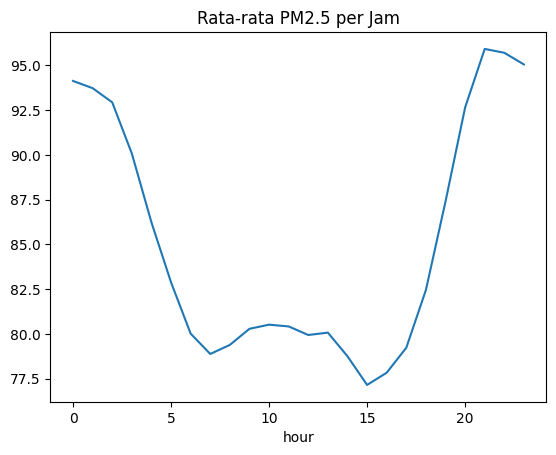

Jam polusi tertinggi: 21
Nilai PM2.5: 95.91456143031547


In [28]:
mean_hour = df.groupby('hour')['PM2.5'].mean()

mean_hour.plot(title='Rata-rata PM2.5 per Jam')
plt.show()

peak_hour = mean_hour.idxmax()
peak_value = mean_hour.max()

print("Jam polusi tertinggi:", peak_hour)
print("Nilai PM2.5:", peak_value)

**Insight:**
Polusi tertinggi terjadi pada jam tertentu, lebih tepatnya di jam 21.00 sehingga pada waktu tersebut sebaiknya dilakukan pembatasan aktivitas luar ruangan untuk mengurangi risiko kesehatan.

### Pertanyaan 2:

In [29]:
best_hour = mean_hour.idxmin()
best_value = mean_hour.min()

print("Jam terbaik:", best_hour)
print("PM2.5 terendah:", best_value)

Jam terbaik: 15
PM2.5 terendah: 77.1537872923572


**Insight:**
Waktu dengan PM2.5 terendah merupakan waktu terbaik untuk aktivitas luar ruangan seperti olahraga, yaitu di jam 15.00

### Pertanyaan 3:

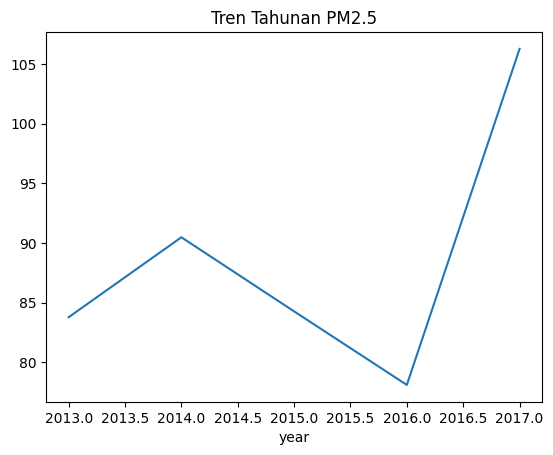

In [30]:
yearly = df.groupby('year')['PM2.5'].mean()

yearly.plot(title='Tren Tahunan PM2.5')
plt.show()

**Insight:**
Terlihat bahwa tingkat polusi PM2.5 mengalami fluktuasi dari tahun ke tahun. Setelah mengalami penurunan pada periode 2014–2016, terjadi peningkatan yang cukup signifikan pada tahun 2017.
Hal ini menunjukkan bahwa meskipun sempat terjadi perbaikan kualitas udara, kondisi tersebut tidak stabil dan dapat kembali memburuk.
Pemerintah tidak dapat hanya mengandalkan kebijakan jangka pendek, tetapi perlu merancang strategi pengendalian polusi yang berkelanjutan dan konsisten untuk mencegah lonjakan polusi di masa mendatang.

## Conclusion

Berdasarkan hasil analisis, analisis waktu menunjukkan bahwa kualitas udara terbaik terjadi pada pukul 15.00, sehingga waktu tersebut direkomendasikan untuk aktivitas luar ruangan. Sebaliknya, tingkat polusi tertinggi terjadi pada pukul 21.00, sehingga perlu dilakukan pembatasan aktivitas luar ruangan pada jam tersebut untuk mengurangi risiko kesehatan masyarakat.
Selain itu, kualitas udara menunjukkan pola yang fluktuatif dari tahun ke tahun dan tidak stabil, dengan adanya peningkatan signifikan pada periode tertentu. Hal ini mengindikasikan bahwa perbaikan kualitas udara yang terjadi sebelumnya belum bersifat permanen sehingga diperlukan strategi pengendalian polusi yang berkelanjutan dan konsisten.
